# Notebook 4 - Applying frequency shift due to density change in graphite

- as we saw in previous notebook, density will shift the frequencies of the peaks in a solid, even if the velocity of sound is unchanged
- here we will apply this idea to crystal graphite by shifting the frequencies by a multiplicative factor $a = (\rho_{\rm dis} / \rho_{\rm crys})^{1/3}$, then recalculating the VDOS and group velocity as a function of frequency in preparation for fitting of the disorder linewidth

In [1]:
# load the required libraries
import sys

import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from ase.io import read

from tqdm import tqdm

from smooth_disorder.structural import obtain_density, THzToCm, THz, Angstrom
from smooth_disorder.vis.interactive import *

from smooth_disorder.disorder_linewidth import lorentzian_numpy, flatten_arrays
from smooth_disorder.disorder_linewidth import calculate_vdos_and_average_speed_with_frequency
from smooth_disorder.disorder_linewidth import save_vdos_speed_data_to_files

In [2]:
CRYSTAL_POSCAR   = "./1_graphite/POSCAR"
DISORDERED_POSCAR      = "./2_irg_t2/irg_t2_14009.vasp"

WORK_DIR = "./dl_tutorial"

MESH_SAVE        = f"{WORK_DIR}/mesh_data"
SHIFTED_SAVE          = f"{WORK_DIR}/reduced_density_crystal_vdos_group_vel"

# Lorentzian half-width η for VDOS broadening [cm⁻¹].
# Controls spectral resolution — typical value for graphite: 0.6 cm⁻¹.
GAMMA_BROADENING = 0.6

In [3]:
# we use the prepared density function
density_crystal = obtain_density(read(CRYSTAL_POSCAR))
density_disordered = obtain_density(read(DISORDERED_POSCAR))

density_factor = np.power(density_disordered/density_crystal, 1/3)
print(f"  ρ_crystal    = {density_crystal:.4f} g/cm³")
print(f"  ρ_disordered = {density_disordered:.4f} g/cm³")
print(f"  Density factor = (ρ_dis/ρ_crys)^(1/3) = {density_factor:.4f}")

  ρ_crystal    = 2.2200 g/cm³
  ρ_disordered = 1.9890 g/cm³
  Density factor = (ρ_dis/ρ_crys)^(1/3) = 0.9640


## Recalculate the vdos of the crystal with shifted frequencies


In [4]:
# load the mesh data
with h5py.File(f"{MESH_SAVE}.hdf5", "r") as f:
    frequencies_cm      = np.asarray(f["frequencies_cm"])       # (N_qpts, N_bands) [cm⁻¹]
    weights             = np.asarray(f["weights"])              # (N_qpts,)
    qpoints             = np.asarray(f["qpoints"])              # (N_qpts, 3) fractional
    group_velocities_ms = np.asarray(f["group_velocities_ms"])  # (N_qpts, N_bands, 3) [m/s]

In [5]:
# flatten the arrays for easier VDOS calculation
frequencies_flat, weights_flat, speed_flat, weights_sum = flatten_arrays(
    frequencies_cm,
    weights,
    group_velocities_ms)

# we shift the frequencies by the multiplicative factor
shifted_frequencies_flat = frequencies_flat * density_factor

shifted_vdos_crystal, shifted_speed_crystal, shifted_freq_crystal = calculate_vdos_and_average_speed_with_frequency(
    shifted_frequencies_flat,
    weights_flat,
    speed_flat,
    GAMMA_BROADENING,
    CRYSTAL_POSCAR,
    weights_sum
)

VDOS & v(w): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12931/12931 [01:21<00:00, 159.62it/s]


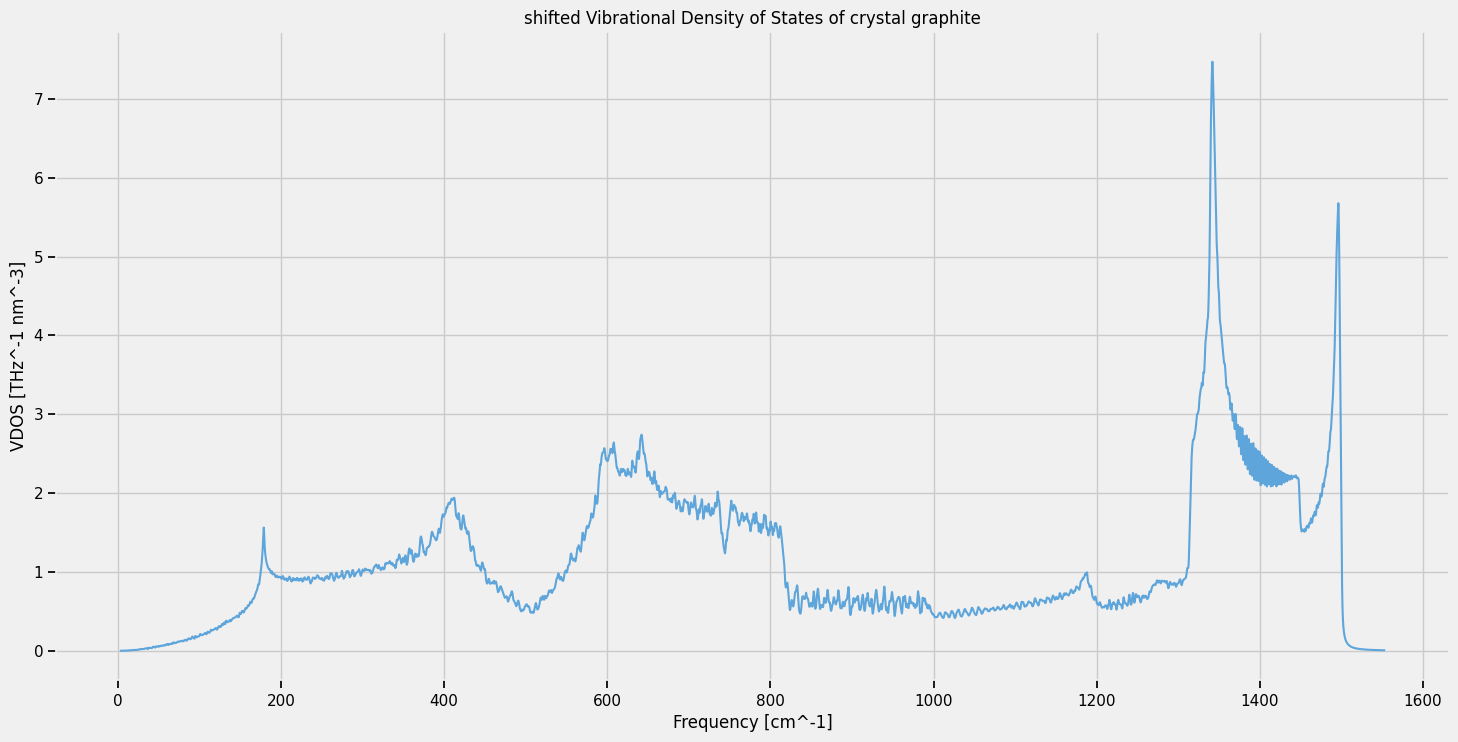

In [6]:
plt.figure(figsize=(16, 8))

plt.plot(shifted_freq_crystal, shifted_vdos_crystal, color=Colors[3])

plt.xlabel("Frequency [cm^-1]")
plt.ylabel("VDOS [THz^-1 nm^-3]")

plt.title("shifted Vibrational Density of States of crystal graphite")

plt.show()

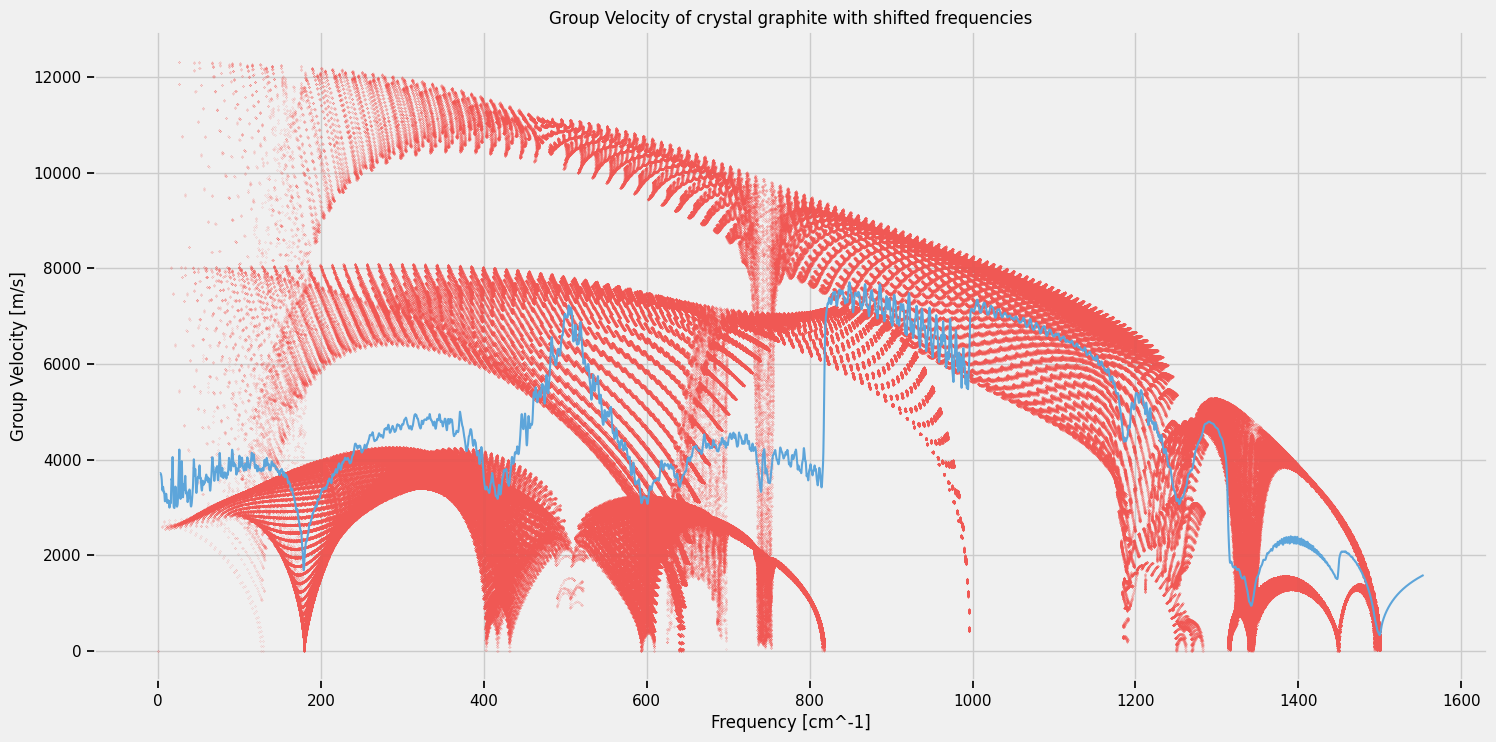

In [7]:
plt.figure(figsize=(16, 8))

plt.scatter(shifted_frequencies_flat, speed_flat, color=Colors[0], s=0.01)
plt.plot(shifted_freq_crystal, shifted_speed_crystal, color=Colors[3])

plt.xlabel("Frequency [cm^-1]")
plt.ylabel("Group Velocity [m/s]")

plt.title("Group Velocity of crystal graphite with shifted frequencies")

plt.show()

In [8]:
save_vdos_speed_data_to_files(SHIFTED_SAVE, shifted_freq_crystal, shifted_vdos_crystal, shifted_speed_crystal)